## Subgraphs — Modular, Reusable Nested Graphs in LangGraph


In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator


# --- 1. SUBGRAPH ---
class ValidationState(TypedDict):
    text: str
    errors: Annotated[list[str], operator.add]
    is_valid: bool


def check_length(state: ValidationState) -> dict:
    return {"errors": ["Too short (min 5)"]} if len(state["text"]) < 5 else {"errors": []}


def check_no_digits(state: ValidationState) -> dict:
    return {"errors": ["No numbers allowed"]} if any(c.isdigit() for c in state["text"]) else {"errors": []}


def set_validity(state: ValidationState) -> dict:
    return {"is_valid": len(state["errors"]) == 0}


sub = StateGraph(ValidationState)
sub.add_node("len", check_length)
sub.add_node("digits", check_no_digits)
sub.add_node("validity", set_validity)
sub.add_edge(START, "len")
sub.add_edge("len", "digits")
sub.add_edge("digits", "validity")
sub.add_edge("validity", END)
validation_subgraph = sub.compile()

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator


# --- 2. PARENT GRAPH ---
class ParentState(TypedDict):
    raw_input: str
    text: str
    errors: Annotated[list[str], operator.add]
    is_valid: bool
    final_output: str


def preprocess(state: ParentState) -> dict:
    return {
        "text": state["raw_input"].strip(),
        "errors": [],
    }


def handle_valid(state: ParentState) -> dict:
    return {"final_output": f"✅ Accepted: '{state['text']}'"}


def handle_invalid(state: ParentState) -> dict:
    return {"final_output": f"❌ Rejected: {', '.join(state['errors'])}"}


parent = StateGraph(ParentState)
parent.add_node("preprocess", preprocess)
parent.add_node("validate", validation_subgraph)  # ← subgraph as a node
parent.add_node("valid", handle_valid)
parent.add_node("invalid", handle_invalid)
parent.add_edge(START, "preprocess")
parent.add_edge("preprocess", "validate")
parent.add_conditional_edges(
    "validate",
    lambda _state: "valid" if _state["is_valid"] else "invalid",
    {
        "valid": "valid",
        "invalid": "invalid",
    },
)
parent.add_edge("valid", END)
parent.add_edge("invalid", END)
graph = parent.compile()

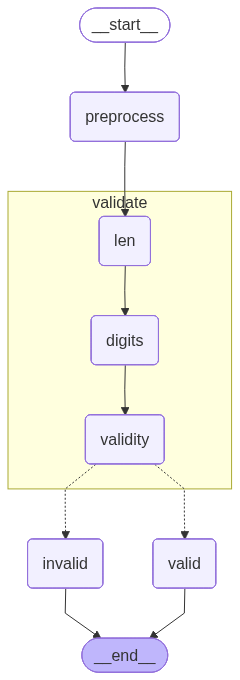

In [4]:
# --- 3. VISUALIZE (xray=True shows inside subgraph) ---
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [6]:
# --- 4. RUN & TEST ---
for inp in ["Hi", "Hello World", "Hello123", "  LangGraph  ", "Hi12"]:
    response = graph.invoke(
        {
            "raw_input": inp,
            "text": "",
            "errors": [],
            "is_valid": True,
            "final_output": "",
        }
    )
    print(f"{inp!r:20} → {response['final_output']}")

'Hi'                 → ❌ Rejected: Too short (min 5)
'Hello World'        → ✅ Accepted: 'Hello World'
'Hello123'           → ❌ Rejected: No numbers allowed
'  LangGraph  '      → ✅ Accepted: 'LangGraph'
'Hi12'               → ❌ Rejected: Too short (min 5), No numbers allowed
